In [1]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import numpy as np
import matplotlib.pyplot as plt


In [2]:
model = load_model("cnn_leaf_classifier.h5")
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         4,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,042 (24.88 MB)

 Trainable params: 6,520,592 (24.87 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 2 (12.00 B)

In [4]:
train_dir = "Phase1/Week2/plantdisease/PlantVillage"


In [7]:
import os
print(os.getcwd())


d:\DL_continued\deep-learning-journey\Phase1\Week2


In [8]:
import os
print(os.listdir())


['.vscode', 'cnn_leaf_classifier.h5', 'cnn_leaf_classifier.ipynb', 'dataset', 'notes.md', 'plantdisease', 'plantdisease.zip', 'README.md']


In [9]:
import os
print(os.listdir("dataset"))


print(os.listdir("plantdisease"))


['PlantVillage']
['PlantVillage']


In [10]:
train_dir = "dataset/PlantVillage"


In [19]:
img_size = (224, 224)
batch_size = 32

train_dir = "dataset/PlantVillage"

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode='int',
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode='int',
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
class_names


Found 32046 files belonging to 16 classes.
Using 25637 files for training.
Found 32046 files belonging to 16 classes.
Using 6409 files for validation.


['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'PlantVillage',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [20]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt


In [21]:
class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)


Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [22]:
base_model = ResNet50(
    weights='imagenet',        # use pretrained ImageNet weights
    include_top=False,         # remove old classifier layer
    input_shape=(224, 224, 3)  # standard ResNet input size
)


In [23]:
base_model.trainable = False


In [24]:
x = base_model.output
x = GlobalAveragePooling2D()(x)   # reduce features into one vector
x = Dropout(0.3)(x)               # prevent overfitting
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)


In [25]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5


ValueError: Input 0 of layer "functional_18" is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 128, 128, 3)

In [ ]:
model.save("resnet50_leaf_disease.h5")


In [26]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory


In [27]:
print(os.getcwd())


d:\DL_continued\deep-learning-journey\Phase1\Week2


In [28]:
print(os.listdir())


['.vscode', 'cnn_leaf_classifier.h5', 'cnn_leaf_classifier.ipynb', 'dataset', 'notes.md', 'plantdisease', 'plantdisease.zip', 'README.md']


In [29]:
img_size = (224, 224)
batch_size = 32

train_dir = "plantdisease/PlantVillage"

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode='int',
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode='int',
    image_size=img_size,
    batch_size=batch_size
)


Found 41276 files belonging to 16 classes.
Using 33021 files for training.
Found 41276 files belonging to 16 classes.
Using 8255 files for validation.


In [30]:
for x, y in train_ds.take(1):
    print("Image batch shape:", x.shape)


Image batch shape: (32, 224, 224, 3)


In [31]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pretrained ResNet50 without the classifier:
base_model = ResNet50(
    weights='imagenet',        # use pretrained weights
    include_top=False,         # remove ImageNet classifier
    input_shape=(224, 224, 3)
)

# Freeze the base model so we don't break pretrained knowledge
base_model.trainable = False

print("ResNet50 base model loaded and frozen.")


ResNet50 base model loaded and frozen.


In [32]:
num_classes = len(train_ds.class_names)

x = base_model.output
x = GlobalAveragePooling2D()(x)    # convert features → vector
x = Dropout(0.3)(x)                # regularization
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

# Full model
model = Model(inputs=base_model.input, outputs=output)

print("Model created.")
model.summary()


Model created.


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,116,368 (92.00 MB)

 Trainable params: 528,656 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model compiled.")


Model compiled.


In [34]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1623s 2s/step - accuracy: 0.4766 - loss: 1.2446 - val_accuracy: 0.4832 - val_loss: 0.9703
Epoch 2/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1621s 2s/step - accuracy: 0.4880 - loss: 1.0040 - val_accuracy: 0.4801 - val_loss: 0.9035
Epoch 3/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1596s 2s/step - accuracy: 0.4921 - loss: 0.9494 - val_accuracy: 0.4730 - val_loss: 0.8889
Epoch 4/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1581s 2s/step - accuracy: 0.4945 - loss: 0.9204 - val_accuracy: 0.4706 - val_loss: 0.8702
Epoch 5/5
1032/1032 ━━━━━━━━━━━━━━━━━━━━ 1596s 2s/step - accuracy: 0.4927 - loss: 0.8985 - val_accuracy: 0.4693 - val_loss: 0.8602


In [35]:
model.save("resnet50_leaf_disease.h5")
print("Model saved successfully.")


Model saved successfully.


In [36]:
import zipfile
import os

zip_path = "plantdisease.zip"
extract_to = "plantdisease_clean"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Extracted successfully!")
print(os.listdir("plantdisease_clean"))


Extracted successfully!
['PlantVillage']


In [37]:
train_dir = "plantdisease_clean/PlantVillage"

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)


Found 41276 files belonging to 16 classes.
Using 33021 files for training.
Found 41276 files belonging to 16 classes.
Using 8255 files for validation.


In [38]:
print(train_ds.class_names)


['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [39]:
os.listdir("plantdisease_clean")


['PlantVillage']

In [40]:
import os
print(os.listdir("plantdisease_clean/PlantVillage"))


['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [41]:
os.listdir("plantdisease_clean/PlantVillage")


['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'PlantVillage',
 'Potato___Early_blight',
 'Potato___healthy',
 'Potato___Late_blight',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_healthy',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_mosaic_virus',
 'Tomato__Tomato_YellowLeaf__Curl_Virus']

In [42]:
import shutil

bad_path = "plantdisease_clean/PlantVillage/PlantVillage"
shutil.rmtree(bad_path)

print("Removed nested PlantVillage folder successfully!")


Removed nested PlantVillage folder successfully!


In [43]:
print(os.listdir("plantdisease_clean/PlantVillage"))


['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [44]:
img_size = (224, 224)
batch_size = 32

train_dir = "plantdisease_clean/PlantVillage"

train_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    label_mode='int',
    image_size=img_size,
    batch_size=batch_size
)

val_ds = image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    label_mode='int',
    image_size=img_size,
    batch_size=batch_size
)

print("Classes:", train_ds.class_names)


Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [45]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(train_ds.class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,116,111 (92.00 MB)

 Trainable params: 528,399 (2.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [46]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 829s 2s/step - accuracy: 0.7551 - loss: 0.7667 - val_accuracy: 0.9213 - val_loss: 0.2466
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.8759 - loss: 0.3677 - val_accuracy: 0.9435 - val_loss: 0.1757
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 798s 2s/step - accuracy: 0.8998 - loss: 0.2951 - val_accuracy: 0.9426 - val_loss: 0.1738
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 795s 2s/step - accuracy: 0.9157 - loss: 0.2469 - val_accuracy: 0.9494 - val_loss: 0.1497
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.9273 - loss: 0.2123 - val_accuracy: 0.9557 - val_loss: 0.1336


In [47]:
model.save("resnet50_leaf_disease.h5")
print("Model saved successfully!")


Model saved successfully!


In [48]:
import os
print(os.listdir())


['.vscode', 'cnn_leaf_classifier.ipynb', 'notes.md', 'plantdisease.zip', 'plantdisease_clean', 'README.md', 'resnet50_leaf_disease.h5']


In [49]:

# Unfreeze the top layers of ResNet50 for fine-tuning
fine_tune_at = 130  # unfreeze last ~20 layers (ResNet has 176 layers)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

print("Layers unfrozen from:", fine_tune_at)


Layers unfrozen from: 130


In [50]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # very small learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print("Model recompiled for fine-tuning.")


Model recompiled for fine-tuning.


In [51]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)


Epoch 1/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1211s 2s/step - accuracy: 0.9021 - loss: 0.3072 - val_accuracy: 0.9622 - val_loss: 0.1120
Epoch 2/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1161s 2s/step - accuracy: 0.9608 - loss: 0.1140 - val_accuracy: 0.9717 - val_loss: 0.0879
Epoch 3/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1156s 2s/step - accuracy: 0.9806 - loss: 0.0649 - val_accuracy: 0.9765 - val_loss: 0.0726
Epoch 4/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1147s 2s/step - accuracy: 0.9876 - loss: 0.0421 - val_accuracy: 0.9780 - val_loss: 0.0686
Epoch 5/5
516/516 ━━━━━━━━━━━━━━━━━━━━ 1141s 2s/step - accuracy: 0.9912 - loss: 0.0295 - val_accuracy: 0.9794 - val_loss: 0.0636


In [52]:
model.save("resnet50_leaf_disease_finetuned.h5")
print("Fine-tuned model saved.")


Fine-tuned model saved.


In [53]:
for layer in model.layers:
    print(layer.name)


input_layer_3
conv1_pad
conv1_conv
conv1_bn
conv1_relu
pool1_pad
pool1_pool
conv2_block1_1_conv
conv2_block1_1_bn
conv2_block1_1_relu
conv2_block1_2_conv
conv2_block1_2_bn
conv2_block1_2_relu
conv2_block1_0_conv
conv2_block1_3_conv
conv2_block1_0_bn
conv2_block1_3_bn
conv2_block1_add
conv2_block1_out
conv2_block2_1_conv
conv2_block2_1_bn
conv2_block2_1_relu
conv2_block2_2_conv
conv2_block2_2_bn
conv2_block2_2_relu
conv2_block2_3_conv
conv2_block2_3_bn
conv2_block2_add
conv2_block2_out
conv2_block3_1_conv
conv2_block3_1_bn
conv2_block3_1_relu
conv2_block3_2_conv
conv2_block3_2_bn
conv2_block3_2_relu
conv2_block3_3_conv
conv2_block3_3_bn
conv2_block3_add
conv2_block3_out
conv3_block1_1_conv
conv3_block1_1_bn
conv3_block1_1_relu
conv3_block1_2_conv
conv3_block1_2_bn
conv3_block1_2_relu
conv3_block1_0_conv
conv3_block1_3_conv
conv3_block1_0_bn
conv3_block1_3_bn
conv3_block1_add
conv3_block1_out
conv3_block2_1_conv
conv3_block2_1_bn
conv3_block2_1_relu
conv3_block2_2_conv
conv3_block2_2_bn


In [7]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# GRAD-CAM FUNCTION
# ------------------------------
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # 1) Get the model's convolution model: Inputs -> Last conv layer outputs
    last_conv_layer = model.get_layer(last_conv_layer_name)
    heatmap_model = tf.keras.models.Model(
        [model.inputs], 
        [last_conv_layer.output, model.output]
    )

    # 2) Get gradient of the predicted class w.r.t the feature maps
    with tf.GradientTape() as tape:
        conv_outputs, predictions = heatmap_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    grads = tape.gradient(pred_output, conv_outputs)

    # 3) Take mean intensity of gradients (importance weights)
    weights = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 4) Create weighted sum of feature maps
    cam = np.zeros(conv_outputs.shape[1:3], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * conv_outputs[0, :, :, i]

    # 5) Normalize between 0–1
    cam = np.maximum(cam, 0)
    cam = cam / np.max(cam)

    return cam



In [10]:
def display_gradcam(img_path, model, last_conv_layer_name='conv5_block3_out', alpha=0.4):
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array_exp = np.expand_dims(img_array, axis=0)

    # Normalize like training
    img_array_exp = tf.keras.applications.resnet_v2.preprocess_input(img_array_exp)

    # Generate heatmap
    heatmap = make_gradcam_heatmap(img_array_exp, model, last_conv_layer_name)

    # Resize heatmap
    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(
        np.expand_dims(heatmap, axis=-1),
        (224, 224)
    ).numpy().astype("uint8")
    heatmap = np.squeeze(heatmap)

    # Convert original image to numpy array
    img_np = np.array(img) / 255.0

    # Apply jet colormap
    cmap = plt.cm.jet
    heatmap_colored = cmap(heatmap / 255.0)[:, :, :3]  # RGB only

    # Superimpose heatmap on original image
    superimposed_img = heatmap_colored * alpha + img_np

    # Display
    plt.figure(figsize=(8, 8))

    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img_np)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(superimposed_img)
    plt.axis("off")

    plt.show()


In [57]:
img_path = r"Phase1/Week2/plantdisease_clean/PlantVillage/Tomato_Late_blight/00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG"
display_gradcam(img_path, model)


FileNotFoundError: [Errno 2] No such file or directory: 'Phase1/Week2/plantdisease_clean/PlantVillage/Tomato_Late_blight/00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG'

In [59]:
files = os.listdir("Phase1/Week2/plantdisease_clean/PlantVillage/Tomato_Late_blight")
print(files[:10])  # see first 10


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Phase1/Week2/plantdisease_clean/PlantVillage/Tomato_Late_blight'

In [60]:
import os
print(os.listdir("Phase1/Week2"))


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Phase1/Week2'

In [1]:
import os
os.getcwd()


'd:\\DL_continued\\deep-learning-journey\\Phase1\\Week2'

In [16]:
print(os.listdir())
!pip install opencv-python



['.vscode', 'cnn_leaf_classifier.ipynb', 'notes.md', 'plantdisease.zip', 'plantdisease_clean', 'README.md', 'resnet50_leaf_disease.h5', 'resnet50_leaf_disease_finetuned.h5']
Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/39.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.0 MB ? eta -:--:--
    --------------------------------------- 0.5/39.0 MB 1.3 MB/s eta 0:00:30
    --------------------------------------- 0.8/39.0 MB 1.3 MB/s eta 0:00:29
   - -------------------------------------- 1.0/39.0 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.3/39.0 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.6/39.0 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.6/39.0 MB 1.3 MB/s eta 0:00:30
   - -------------------------------------- 1.8/39.0 MB 1.1 MB/s eta 0:00:33


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
print(os.listdir("plantdisease_clean/PlantVillage/Tomato_Late_blight"))


['0003faa8-4b27-4c65-bf42-6d9e352ca1a5___RS_Late.B 4946.JPG', '00355ec2-f12c-4015-b8f9-94354f69ce22___RS_Late.B 5311.JPG', '005a2c1f-4e15-49e4-9e5c-61dc3ecf9708___RS_Late.B 5096.JPG', '005e3b43-9050-47da-9498-f9ecdcc703b3___RS_Late.B 5104.JPG', '008ebb44-eb77-4843-b621-4b88b5df7d43___RS_Late.B 5188.JPG', '00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG', '013f987a-9371-4763-a104-ea6f326e584b___GHLB2 Leaf 8556.JPG', '01425d17-4c97-46e3-b395-c1453b78ab78___GHLB2 Leaf 9100.JPG', '014d4972-1301-46d3-afc4-56470b774137___GHLB2 Leaf 8831.JPG', '014eee0c-8000-4762-b4b8-63ecc2fadc13___GHLB2ES Leaf 69.1.JPG', '01527fac-41e4-484c-af41-1ed7bc3b5ce6___RS_Late.B 6134.JPG', '0172b2ff-6f6f-43e1-9a63-ea4bb2bce450___GHLB_PS Leaf 17 Day 9.jpg', '017a9839-6097-45aa-85b0-3051db151484___RS_Late.B 5125.JPG', '01a68044-9c5b-4658-a944-6108c6862ce7___GHLB Leaf 2.1 Day 16.JPG', '01c391d2-1b3a-4b58-b205-a75674bba6e9___GHLB2 Leaf 8824.JPG', '01cd2d73-c741-45a5-9610-a2cea2266b80___GHLB2 Leaf 121.JPG', '01

In [4]:
from tensorflow.keras.models import load_model

model = load_model("resnet50_leaf_disease_finetuned.h5")
print("Model loaded!")


Model loaded!


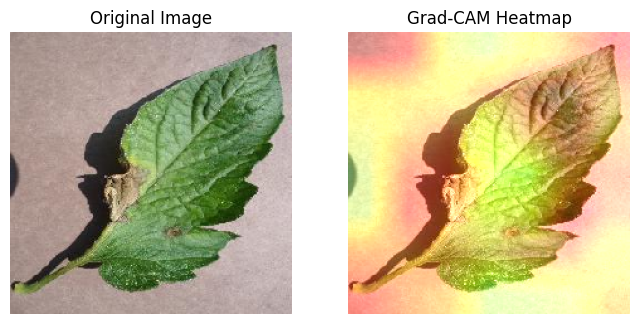

In [11]:
# Choose image
img_path = r"plantdisease_clean/PlantVillage/Tomato_Late_blight/00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG"

# Run Grad-CAM
display_gradcam(img_path, model, last_conv_layer_name="conv5_block3_out")

In [ ]:
def get_gradcam(img_path, model, last_conv_layer_name='conv5_block3_out', alpha=0.4):

    # Load and preprocess image
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    orig_img = img_array.astype("uint8")   # for display later
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Get last conv layer + classifier part
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [last_conv_layer.output, model.output]
    )

    # Compute gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    grads = tape.gradient(pred_output, conv_outputs)

    # Mean intensity of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    # Weight each channel by gradient
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)

    # Normalize heatmap
    heatmap = np.maximum(heatmap, 0)
    heatmap /= np.max(heatmap)

    # Resize heatmap to 224×224
    heatmap = cv2.resize(heatmap.numpy(), (224, 224))

    # Convert heatmap to RGB
    heatmap_colored = plt.cm.jet(heatmap)[:, :, :3]  # No alpha channel

    # Superimpose
    superimposed_img = heatmap_colored * alpha + (orig_img / 255.0)

    return orig_img, heatmap, superimposed_img






In [17]:
img_path = r"plantdisease_clean/PlantVillage/Tomato_Late_blight/00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG"
from tensorflow.keras.applications.resnet50 import preprocess_input
import cv2


orig, heatmap, gradcam_output = get_gradcam(img_path, model)


C:\Users\chala\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_3']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


AttributeError: 'numpy.ndarray' object has no attribute 'numpy'

In [23]:
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model


In [24]:
def display_gradcam(img_path, model, last_conv_layer_name="conv5_block3_out", alpha=0.4):
    # Load image
    img = image.load_img(img_path, target_size=(224, 224))
    img_np = image.img_to_array(img)
    img_batch = np.expand_dims(img_np, axis=0)

    # Preprocess for ResNet50
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(img_batch.copy())

    # Create grad model
    grad_model = Model(
        inputs=model.input,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Compute the gradient of the predicted class w.r.t conv layer activations
    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(img_preprocessed)
        pred_index = tf.argmax(predictions[0])
        pred_output = predictions[:, pred_index]

    grads = tape.gradient(pred_output, conv_output)

    # Convert to numpy arrays
    conv_output = conv_output[0].numpy()      # shape (7,7,2048)
    grads = grads[0].numpy()                  # shape (7,7,2048)

    # Compute channel-wise weights
    weights = np.mean(grads, axis=(0, 1))

    # Weighted sum for heatmap
    cam = np.zeros(conv_output.shape[:2], dtype=np.float32)

    for i, w in enumerate(weights):
        cam += w * conv_output[:, :, i]

    # Normalize heatmap
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)
    cam = cv2.resize(cam, (224, 224))

    # Apply heatmap
    heatmap = cv2.applyColorMap((cam * 255).astype("uint8"), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # Superimpose
    superimposed = heatmap * alpha + img_np

    # Display
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(img_np.astype("uint8"))
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(superimposed.astype("uint8"))
    plt.axis("off")

    plt.show()


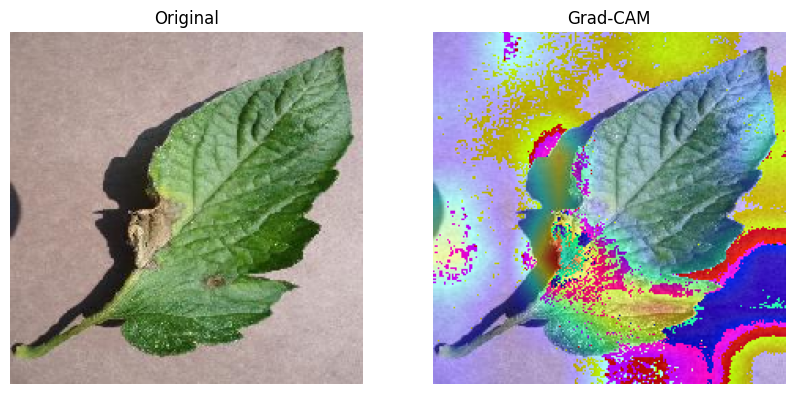

In [25]:
img_path = r"plantdisease_clean/PlantVillage/Tomato_Late_blight/00ce4c63-9913-4b16-898c-29f99acf0dc3___RS_Late.B 4982.JPG"
display_gradcam(img_path, model)
